In [ ]:
!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


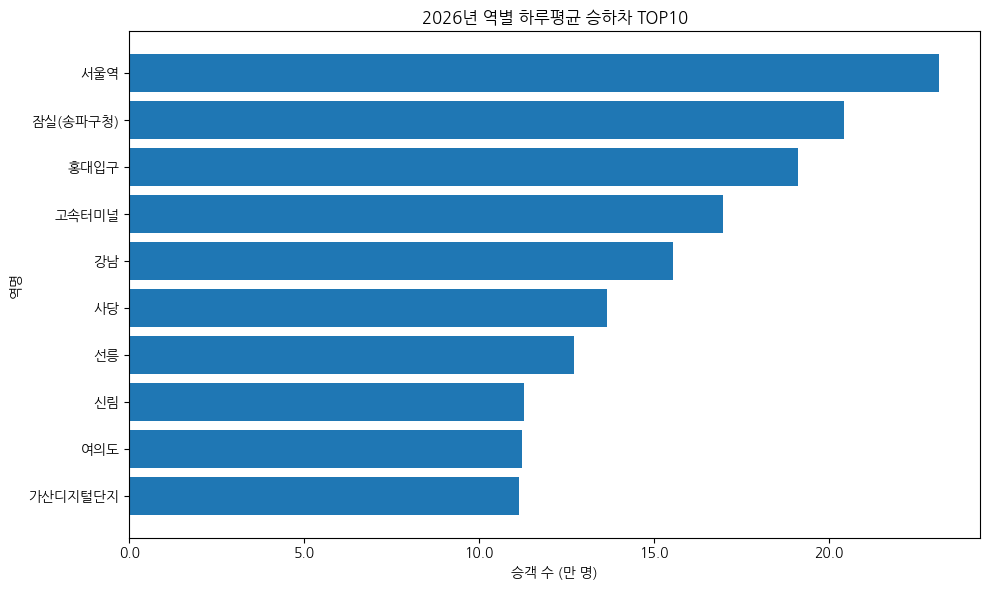

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df = pd.read_csv("result_year_station_top10.csv")

year = 2026
temp = df[df["year"] == year].sort_values(
    "daily_avg_passenger",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(temp["station"], temp["daily_avg_passenger"])
plt.title(f"{year}년 역별 하루평균 승하차 TOP10")
plt.xlabel("승객 수 (만 명)")
plt.ylabel("역명")






ax = plt.gca()




ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/10000:.1f}")
)

plt.tight_layout()
plt.show()

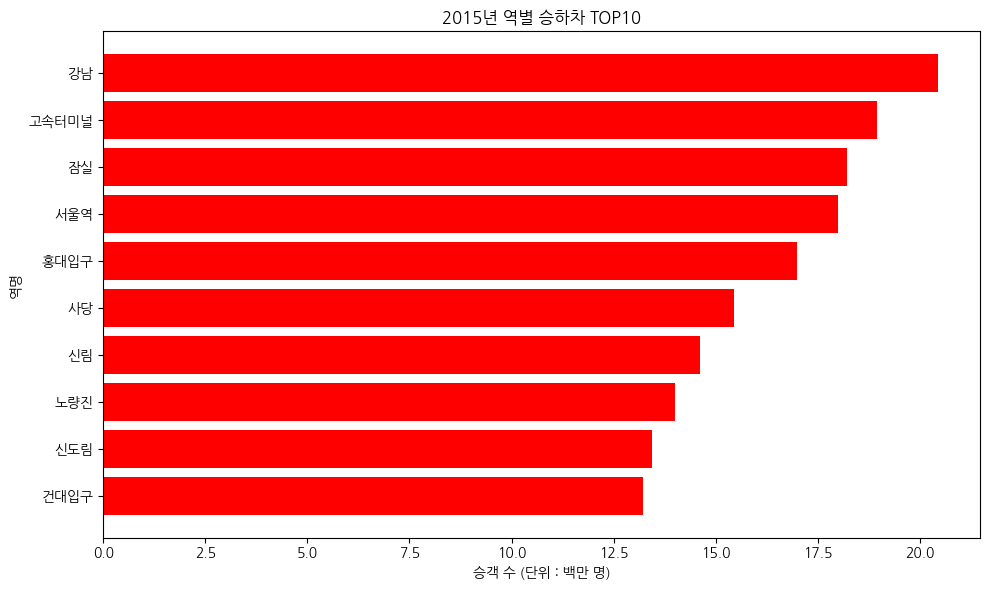

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df = pd.read_csv("result_year_station_top10.csv")

year = 2015
temp = df[df["year"] == year].sort_values(
    "daily_avg_passenger",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(temp["station"], temp["daily_avg_passenger"], color = "red")

plt.title(f"{year}년 역별 승하차 TOP10")
plt.xlabel("승객 수 (단위 : 백만 명)")
plt.ylabel("역명")






ax = plt.gca()
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/10000:.1f}")
)

plt.tight_layout()
plt.show()

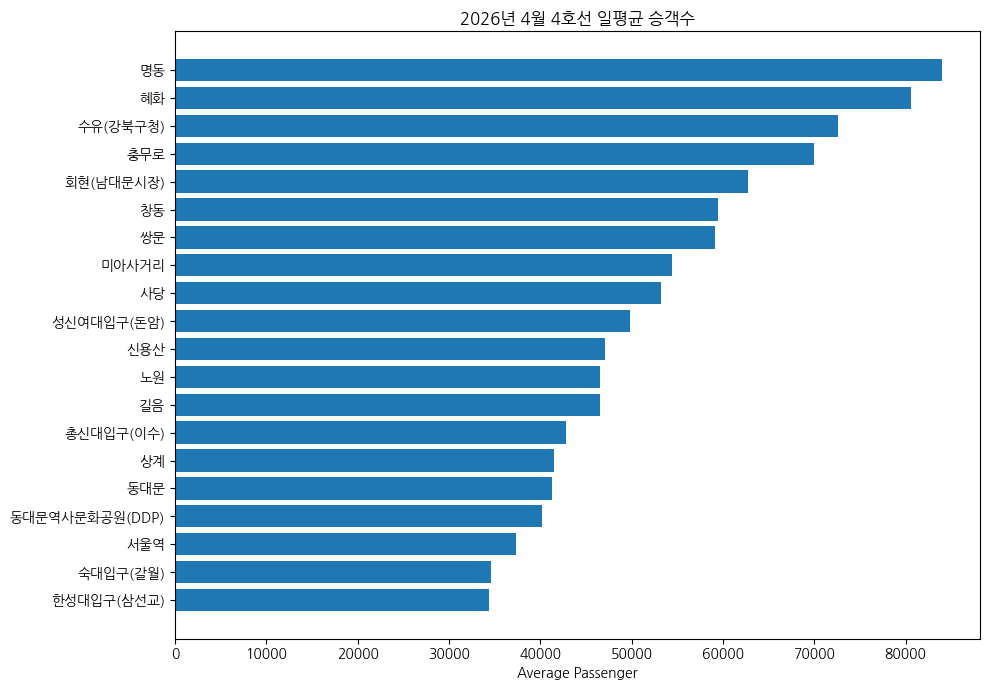

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("result_line4_rank.csv")
top20 = df.head(20)
plt.figure(figsize=(10,7))

plt.barh(
    top20["station"],
    top20["avg_passenger"]
)

plt.gca().invert_yaxis()

plt.title(
    "2026년 4월 4호선 일평균 승객수"
)







plt.xlabel("Average Passenger")
plt.tight_layout()

plt.show()

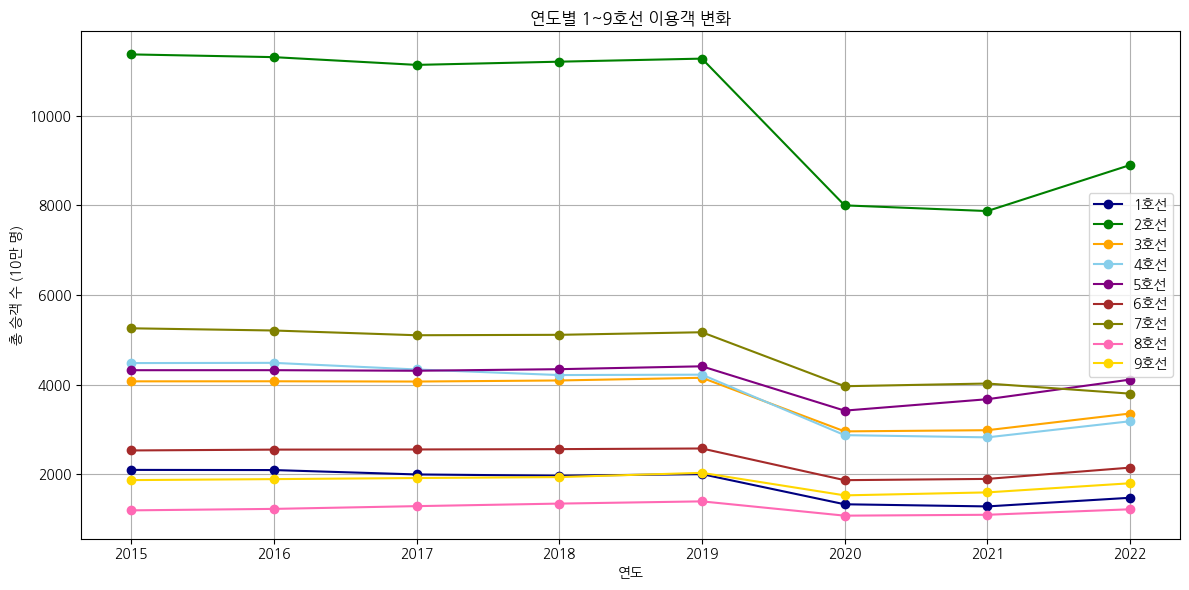

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df = pd.read_csv("result_year_line_change.csv")

target_lines = ["1호선", "2호선", "3호선", "4호선",
                "5호선", "6호선", "7호선", "8호선", "9호선"]

df = df[df["line"].isin(target_lines)]
df = df[~df["year"].isin([2025, 2026])]

pivot = df.pivot(
    index="year",
    columns="line",
    values="total_passenger"
)

#호선별 색상으로 맞추었습니다.
line_colors = {
    "1호선": "navy",
    "2호선": "green",
    "3호선": "orange",
    "4호선": "skyblue",
    "5호선": "purple",
    "6호선": "brown",
    "7호선": "olive",
    "8호선": "hotpink",
    "9호선": "gold"
}

plt.figure(figsize=(12,6))

for col in target_lines:
    if col in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[col],
            marker="o",
            label=col,
            color=line_colors[col]
        )

ax = plt.gca()

# 10만명 단위 표시
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: f"{x/100000:.0f}"
    )
)

plt.legend()
plt.title("연도별 1~9호선 이용객 변화")
plt.xlabel("연도")
plt.ylabel("총 승객 수 (10만 명)")
plt.grid()
plt.tight_layout()
plt.show()